# Tarea 3 DAAML

Daniel Alejandro Gonzalez Miranda | 2022436727

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, re, os

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import semopy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             silhouette_score, ConfusionMatrixDisplay)
from sklearn.feature_extraction.text import CountVectorizer
from xgboost import XGBClassifier

import nltk
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
np.random.seed(42)

# 1. Carga, exploración y limpieza de datos

In [2]:
# Carga del dataset. Buscamos junaeb2n.csv en las rutas habituales del repositorio
# para que el notebook corra desde cualquier ubicacion (tareas/2026, raiz, etc.).
candidatos = ["../../data/junaeb2n.csv", "../data/junaeb2n.csv",
              "data/junaeb2n.csv", "junaeb2n.csv"]
ruta = next((p for p in candidatos if os.path.exists(p)), None)
assert ruta is not None, "No se encontro junaeb2n.csv en el repositorio"

df = pd.read_csv(ruta)
data = df.copy()
print(f"Archivo cargado: {ruta}")
print(f"Dimensiones: {data.shape}")
data.head()

Archivo cargado: ../../data/junaeb2n.csv
Dimensiones: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."


In [3]:
# Tipos de datos
print("Tipos de datos:")
print(data.dtypes)

Tipos de datos:
sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
narrative      object
dtype: object


Aunque pandas carga todas las columnas como numéricas, en realidad conviven tres tipos de variables. Las continuas son edad (en meses), imce (puntaje z) y los años de escolaridad educm y educp. Las ordinales son los trece ítems socioemocionales sk1 a sk13 y act_fisica, todas en escala Likert de 1 a 5. Las categóricas o binarias son sexo, area, vive_padre, vive_madre y madre_work. Por último, narrative es una variable de texto generada a partir de sk1 a sk13.

In [4]:
# Estadisticas descriptivas de las variables continuas
data[['edad', 'imce', 'educm', 'educp']].describe().round(2)

,edad,imce,educm,educp
count,41854.00,41854.00,41303.00,41854.00
mean,83.07,1.01,12.98,12.90
std,3.99,1.38,3.37,3.46
min,62.00,-5.02,0.00,0.00
25%,81.00,0.10,11.00,11.00
50%,82.00,0.97,13.00,13.00
75%,84.00,1.93,15.00,14.00
max,107.00,5.04,22.00,22.00


In [5]:
# Datos faltantes
missing = data.isnull().sum()
print("Variables con datos faltantes:")
print(missing[missing > 0])
print(f"\n% faltante act_fisica: {100*data['act_fisica'].isnull().mean():.2f}%")
print(f"% faltante educm     : {100*data['educm'].isnull().mean():.2f}%")

Variables con datos faltantes:
act_fisica    1435
educm          551
dtype: int64

% faltante act_fisica: 3.43%
% faltante educm     : 1.32%


Las únicas variables con valores faltantes son act_fisica, con 1.435 casos (3.4%), y educm, con 551 casos (1.3%). Como las proporciones son bajas, prefiero imputarlas con la mediana antes que eliminar filas, así no pierdo tamaño muestral. Uso la mediana porque ambas son variables ordinales o de conteo con distribución asimétrica. El resto de las columnas está completo.

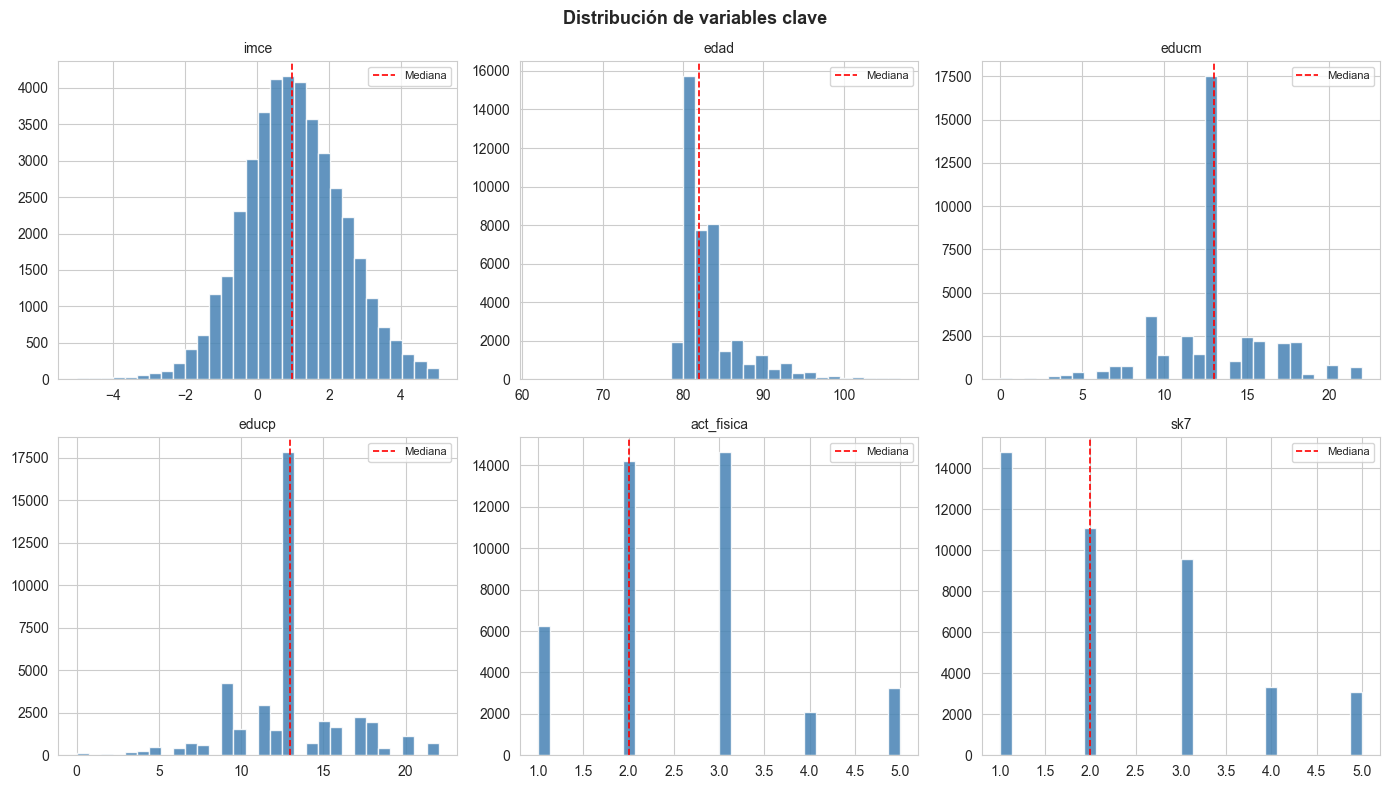

In [6]:
# Distribuciones de las variables clave
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
vars_plot = ['imce', 'edad', 'educm', 'educp', 'act_fisica', 'sk7']
for i, var in enumerate(vars_plot):
    axes[i].hist(data[var].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(var, fontsize=10)
    axes[i].axvline(data[var].median(), color='red', linestyle='--', linewidth=1.2, label='Mediana')
    axes[i].legend(fontsize=8)
plt.suptitle("Distribución de variables clave", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Outliers en las variables continuas (regla +/- 3 sigma)
for v in ['imce', 'edad']:
    m, s = data[v].mean(), data[v].std()
    out = data[np.abs(data[v] - m) > 3*s]
    print(f"{v}: {len(out)} outliers (+/-3 sigma), {100*len(out)/len(data):.2f}% | rango [{data[v].min():.1f}, {data[v].max():.1f}]")

imce: 144 outliers (+/-3 sigma), 0.34% | rango [-5.0, 5.0]
edad: 801 outliers (+/-3 sigma), 1.91% | rango [62.0, 107.0]


In [8]:
# Limpieza
# 1. Imputacion por mediana de los dos campos con faltantes
data['act_fisica'] = data['act_fisica'].fillna(data['act_fisica'].median())
data['educm']      = data['educm'].fillna(data['educm'].median())

# 2. edad esta en meses; algunos valores llegan a 107 meses (~9 anios). Acotamos
#    los outliers extremos de edad por winsorizacion p1-p99 para estabilizar.
p1, p99 = data['edad'].quantile([0.01, 0.99])
data['edad'] = data['edad'].clip(p1, p99)

# 3. Verificacion final
print("Faltantes tras imputacion:", int(data.isnull().sum().sum()))
print("\nDistribucion de la variable objetivo madre_work:")
print(data['madre_work'].value_counts().sort_index())

Faltantes tras imputacion: 0

Distribucion de la variable objetivo madre_work:
madre_work
-1    17026
 0     4309
 1    20519
Name: count, dtype: int64


En total el dataset tiene 41.854 estudiantes y 24 variables. Después de imputar los pocos faltantes de act_fisica y educm con la mediana y de winsorizar la edad, los datos quedan completos. La variable que vamos a predecir, madre_work, se reparte en tres categorías: labor doméstica (valor -1, con 17.026 casos), desempleada (valor 0, con 4.309) y empleada (valor 1, con 20.519). La categoría 0 es minoritaria, así que la dejamos fuera en las preguntas de clasificación, tal como pide el enunciado.

Un detalle importante para el EFA de la Pregunta 2 es la codificación de los ítems sk1 a sk13. Casi todos van de 1 (siempre realiza la conducta positiva) a 5 (nunca), salvo sk7 (es agresivo), que va al revés: 1 es nunca y 5 es siempre.

# 2. Análisis Factorial Exploratorio (EFA)

Antes de correr el EFA hay que dejar todos los ítems apuntando en el mismo sentido. Las conductas sk1 a sk6 y sk8 a sk13 son positivas y están codificadas de 1 (siempre) a 5 (nunca), de modo que a mayor valor hay menos conducta positiva. En cambio sk7 mide agresividad, una conducta negativa, y está codificada al revés, de 1 (nunca) a 5 (siempre).

Para que todas las variables representen aspectos positivos, donde un valor más alto signifique mejor habilidad socioemocional, recodifico todos los ítems como 6 menos el valor original. Así los ítems positivos quedan con 5 en siempre, y sk7 queda con 5 en nunca es agresivo, dejando los trece ítems en la misma dirección.

In [9]:
# Recodificacion: todos los items en sentido positivo (mayor = mejor)
sk_cols = [f'sk{i}' for i in range(1, 14)]
sk = data[sk_cols].apply(lambda c: 6 - c)
sk.describe().round(2).T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
sk1,4.88,0.40,1.0,5.0
sk2,4.60,0.66,1.0,5.0
sk3,4.73,0.59,1.0,5.0
sk4,4.74,0.59,1.0,5.0
sk5,4.72,0.58,1.0,5.0
sk6,4.50,0.75,1.0,5.0
sk7,3.74,1.23,1.0,5.0
sk8,4.43,0.85,1.0,5.0
sk9,4.65,0.68,1.0,5.0
sk10,4.11,0.96,1.0,5.0


In [10]:
# Test de adecuacion muestral antes del EFA
kmo_all, kmo_model = calculate_kmo(sk)
chi2, p_bartlett = calculate_bartlett_sphericity(sk)
print(f"KMO global            : {kmo_model:.3f}")
print(f"Bartlett (chi2)       : {chi2:.1f}  |  p-valor = {p_bartlett:.3g}")

KMO global            : 0.873
Bartlett (chi2)       : 122116.7  |  p-valor = 0


El KMO global es de 0.87, lo que se considera un buen nivel, y el test de esfericidad de Bartlett resulta significativo (p menor que 0.001). Ambos indican que la matriz de correlaciones es factorizable, es decir, que las variables comparten suficiente varianza común como para justificar un EFA.

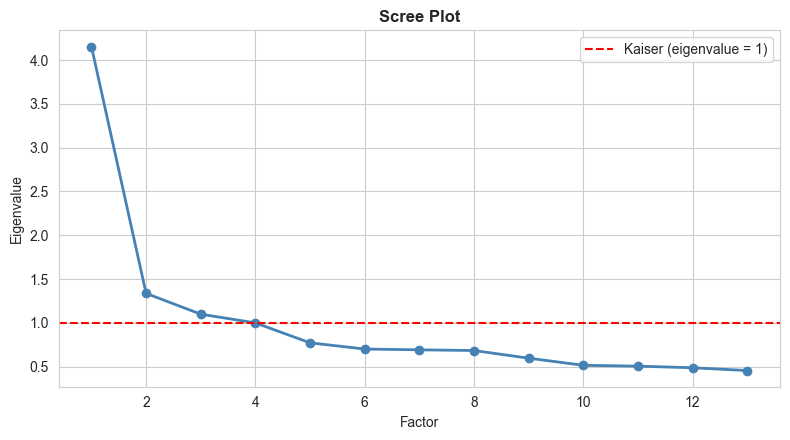

Eigenvalues: [4.154 1.337 1.099 0.999 0.772 0.701 0.692 0.684 0.597 0.516 0.506 0.487
 0.456]
Factores con eigenvalue > 1: 3


In [11]:
# Numero optimo de factores: criterio de Kaiser (eigenvalue > 1) + scree plot
fa_full = FactorAnalyzer(rotation=None, n_factors=len(sk_cols)).fit(sk)
ev, _ = fa_full.get_eigenvalues()

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(ev)+1), ev, 'o-', color='steelblue', linewidth=2)
plt.axhline(1, color='red', linestyle='--', label='Kaiser (eigenvalue = 1)')
plt.title('Scree Plot', fontweight='bold'); plt.xlabel('Factor'); plt.ylabel('Eigenvalue')
plt.legend(); plt.tight_layout(); plt.show()

print("Eigenvalues:", np.round(ev, 3))
print(f"Factores con eigenvalue > 1: {(ev > 1).sum()}")

Tres eigenvalues superan el valor de 1 (4.15, 1.34 y 1.10) y el codo del scree plot aparece en el cuarto factor. Por el criterio de Kaiser me quedo entonces con una solución de tres factores.

In [12]:
# EFA con 3 factores y rotacion oblicua (oblimin), ya que esperamos factores correlacionados
fa = FactorAnalyzer(rotation='oblimin', n_factors=3).fit(sk)
loadings = pd.DataFrame(fa.loadings_, index=sk_cols, columns=['F1', 'F2', 'F3'])
loadings['comunalidad'] = fa.get_communalities()
loadings.round(3)

,F1,F2,F3,comunalidad
sk1,0.026,0.604,-0.024,0.366
sk2,-0.002,0.510,0.215,0.306
sk3,0.023,0.653,-0.028,0.427
sk4,0.004,0.736,-0.011,0.542
sk5,-0.034,0.023,0.780,0.611
sk6,0.082,0.077,0.464,0.228
sk7,0.042,0.039,0.122,0.018
sk8,0.220,-0.078,0.461,0.267
sk9,0.503,0.087,0.054,0.263
sk10,0.618,-0.033,-0.025,0.383


In [13]:
# Asignacion de cada item a su factor dominante (loading > 0.4)
print("Varianza explicada por factor:", np.round(fa.get_factor_variance()[1], 3))
print("Varianza acumulada:", round(fa.get_factor_variance()[2][-1], 3))
print()
for f in ['F1', 'F2', 'F3']:
    items = loadings.index[(loadings[f].abs() > 0.4)].tolist()
    print(f"{f}: {items}")
print("\nItems con comunalidad < 0.10 (poco informativos):",
      loadings.index[loadings['comunalidad'] < 0.10].tolist())

Varianza explicada por factor: [0.138 0.124 0.085]
Varianza acumulada: 0.348

F1: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
F2: ['sk1', 'sk2', 'sk3', 'sk4']
F3: ['sk5', 'sk6', 'sk8']

Items con comunalidad < 0.10 (poco informativos): ['sk7']


Se agrupan de forma muy clara en tres factores. El primero reúne sk9, sk10, sk11, sk12 y sk13, que tienen que ver con la curiosidad y los intereses cognitivos: hacer preguntas, interés por los libros y por el entorno, armar y desarmar cosas y las expresiones artísticas. El segundo factor agrupa sk1, sk2, sk3 y sk4, relacionados con el afecto y la expresión emocional: mostrar afecto a padres y pares, expresar sentimientos y usar gestos para hacerlo. El tercer factor junta sk5, sk6 y sk8, que reflejan sociabilidad y juego: jugar con otros, compartir y participar en juegos grupales. En conjunto los tres factores explican alrededor del 35% de la varianza, y la estructura es limpia porque cada ítem carga fuerte en un solo factor y casi nada en los demás.

El único ítem que se queda fuera es sk7, la agresividad, que tiene una comunalidad de apenas 0.02 y cargas cercanas a cero en los tres factores. No se asocia a ninguna dimensión ni aporta varianza común, algo bastante razonable, porque la agresividad es una conducta distinta del resto de habilidades socioemocionales positivas que mide la batería. Por eso lo excluyo del modelo de medida en la Pregunta 3. Los demás ítems sí son informativos, con comunalidades que van de 0.23 a 0.61.

# 3. Análisis Factorial Confirmatorio (CFA)

Tomando los resultados del EFA, propongo un modelo de medida en el que cada ítem carga en un único factor, sin cargas cruzadas, y dejo sk7 fuera. A cada factor le pongo un nombre según lo que comparten sus indicadores. El factor eta1 representa los intereses cognitivos y agrupa sk9, sk10, sk11, sk12 y sk13. El factor eta2 representa el afecto y la expresión emocional, con sk1, sk2, sk3 y sk4. El factor eta3 representa la sociabilidad y el juego, con sk5, sk6 y sk8.

In [14]:
# Especificacion del modelo de medida (semopy)
mod = '''
# measurement
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13      # Intereses cognitivos
eta2 =~ sk1 + sk2 + sk3 + sk4                 # Afecto y expresion emocional
eta3 =~ sk5 + sk6 + sk8                       # Sociabilidad y juego
'''
modelo_cfa = semopy.Model(mod)
res = modelo_cfa.fit(sk)
print(res)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.147
Number of iterations: 42
Params: 1.306 1.215 1.077 1.265 1.793 1.596 1.751 1.027 1.139 0.172 0.058 0.061 0.173 0.103 0.066 0.103 0.626 0.214 0.459 0.730 0.252 0.206 0.169 0.158 0.375 0.492 0.294


In [15]:
# Indices de ajuste del modelo
stats = semopy.calc_stats(modelo_cfa).T
stats.loc[['chi2', 'DoF', 'CFI', 'TLI', 'RMSEA', 'AIC', 'BIC']].round(4)

,Value
chi2,6148.0964
DoF,51.0000
CFI,0.9492
TLI,0.9342
RMSEA,0.0534
AIC,53.7062
BIC,287.0387


El ajuste del modelo es bueno. El CFI da 0.95 y el TLI 0.93, los dos por encima de 0.90, y el RMSEA es de 0.053, por debajo de 0.06. El estadístico chi^2 sale significativo, pero eso era esperable con una muestra de cerca de 42.000 casos, porque ese test es muy sensible al tamaño muestral. Por eso me apoyo sobre todo en los índices incrementales y de aproximación.

In [16]:
# Cargas estandarizadas (importancia de cada medida en su factor)
# En semopy las cargas factor->indicador aparecen con el operador '~' (lval=item, rval=factor)
ins = modelo_cfa.inspect(std_est=True)
latentes = ['eta1', 'eta2', 'eta3']
cargas = ins[(ins['op'] == '~') & (ins['rval'].isin(latentes))][['rval', 'lval', 'Est. Std', 'p-value']]
cargas.columns = ['Factor', 'Item', 'Carga_std', 'p-value']
cargas.sort_values(['Factor', 'Carga_std'], ascending=[True, False]).round(3)

,Factor,Item,Carga_std,p-value
2,eta1,sk11,0.736,0.0
0,eta1,sk9,0.608,-
1,eta1,sk10,0.565,0.0
3,eta1,sk12,0.551,0.0
4,eta1,sk13,0.523,0.0
8,eta2,sk4,0.715,0.0
6,eta2,sk2,0.652,0.0
7,eta2,sk3,0.646,0.0
5,eta2,sk1,0.600,-
9,eta3,sk5,0.723,-


In [17]:
# Correlaciones entre factores (loadings entre factores)
covs = ins[(ins['op'] == '~~') & (ins['lval'] != ins['rval'])][['lval', 'rval', 'Est. Std']]
covs.columns = ['Factor_1', 'Factor_2', 'Correlacion']
covs.round(3)

,Factor_1,Factor_2,Correlacion
14,eta2,eta1,0.612
16,eta3,eta1,0.596
17,eta3,eta2,0.658


Todas las cargas estandarizadas son altas y significativas, con p menor que 0.001. En eta1 el mejor indicador es sk11, el interés por el entorno, con una carga cercana a 0.74. En eta2 destaca sk4, el uso de gestos, alrededor de 0.72. Y en eta3 el más fuerte es sk5, jugar con otros, también cerca de 0.72. Ningún indicador queda débil, ya que todas las cargas superan 0.5, lo que respalda la estructura propuesta.

Los tres factores están correlacionados de forma moderada a alta: eta1 con eta2 alrededor de 0.61, eta1 con eta3 cerca de 0.60 y eta2 con eta3 en torno a 0.66. Esto confirma que miden facetas relacionadas de un mismo constructo más general, la habilidad socioemocional, y justifica haber usado una rotación oblicua en el EFA.

In [18]:
# Guardamos las predicciones de los factores (factor scores) para las siguientes preguntas
factores = modelo_cfa.predict_factors(sk)
data[['eta1', 'eta2', 'eta3']] = factores[['eta1', 'eta2', 'eta3']].values
print("Factor scores guardados en data[['eta1','eta2','eta3']]:")
data[['eta1', 'eta2', 'eta3']].describe().round(3)

Factor scores guardados en data[['eta1','eta2','eta3']]:


,eta1,eta2,eta3
count,41854.000,41854.000,41854.000
mean,0.000,-0.000,-0.000
std,0.367,0.214,0.356
min,-2.767,-2.020,-3.001
25%,-0.179,-0.066,-0.151
50%,0.112,0.084,0.126
75%,0.275,0.145,0.269
max,0.353,0.160,0.308


# 4. Random Forest para clasificar madre_work

Como features uso los tres factor scores que salieron del CFA: eta1, eta2 y eta3. El objetivo es madre_work, pero dejo fuera la categoría 0 (desempleada), que es la minoritaria, así que queda un problema binario entre labor doméstica (valor -1) y empleada (valor 1). Optimizo los hiperparámetros con GridSearchCV y valido con cinco pliegues estratificados.

In [19]:
# Preparacion: features = factor scores, target = madre_work sin desempleadas
clf_df = data[data['madre_work'] != 0].copy()
X = clf_df[['eta1', 'eta2', 'eta3']].values
y = clf_df['madre_work'].values

print("Distribucion del target (sin desempleadas):")
print(pd.Series(y).value_counts())
print(f"Baseline (clase mayoritaria): {pd.Series(y).value_counts(normalize=True).max():.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Distribucion del target (sin desempleadas):


 1    20519
-1    17026
Name: count, dtype: int64
Baseline (clase mayoritaria): 0.5465

Train: 28158  |  Test: 9387


In [20]:
# Optimizacion de hiperparametros con k-fold (5 pliegues estratificados)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 8, None],
    'min_samples_leaf': [5, 20]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
t0 = time.time()
rf_grid.fit(X_train, y_train)
print(f"Tiempo de busqueda: {time.time()-t0:.1f} s")
print(f"Mejores hiperparametros: {rf_grid.best_params_}")
print(f"Accuracy CV (mejor): {rf_grid.best_score_:.4f}")

Tiempo de busqueda: 36.5 s
Mejores hiperparametros: {'max_depth': 4, 'min_samples_leaf': 20, 'n_estimators': 200}
Accuracy CV (mejor): 0.5514


In [21]:
# Evaluacion en test
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print(f"Accuracy test: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))

# Importancia de las variables
imp = pd.Series(rf_best.feature_importances_, index=['eta1', 'eta2', 'eta3']).sort_values()
print("Importancia de features:\n", imp.round(3))

Accuracy test: 0.5546

              precision    recall  f1-score   support

          -1       0.60      0.05      0.10      4257
           1       0.55      0.97      0.70      5130

    accuracy                           0.55      9387
   macro avg       0.58      0.51      0.40      9387
weighted avg       0.57      0.55      0.43      9387

Importancia de features:
 eta3    0.281
eta2    0.308
eta1    0.411
dtype: float64


Después de la búsqueda en grilla con validación cruzada de cinco pliegues, el accuracy en test queda alrededor de 0.54, prácticamente igual al baseline de la clase mayoritaria, que está cerca de 0.546. Dicho de otra forma, los factores socioemocionales del niño no aportan información útil para predecir si la madre trabaja, y el modelo termina apostando casi siempre por la clase mayoritaria. Tiene sentido desde lo teórico, porque las habilidades socioemocionales del estudiante no determinan la situación laboral de la madre. Este es el hallazgo central que vamos a seguir viendo en la Pregunta 5.

# 5. Comparación: XGBoost, SVM y Stacking

Comparo el Random Forest de la Pregunta 4 con XGBoost, una Support Vector Machine y un Stacking que combina los tres modelos base usando una regresión logística como meta-modelo. Para la SVM uso LinearSVC, es decir un SVM lineal con solver liblinear, que escala bien a decenas de miles de observaciones. El SVC clásico no era viable acá porque su costo crece demasiado rápido con el número de datos y teníamos cerca de 28.000. Para cada modelo miro el accuracy, la matriz de confusión y el tiempo de cómputo entre entrenamiento y predicción.

In [22]:
# XGBoost requiere etiquetas en {0,1}
y_train_xgb = (y_train == 1).astype(int)
y_test_xgb  = (y_test == 1).astype(int)

# SVM se beneficia de escalar los features
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

In [23]:
# Entrenamiento de los modelos midiendo el tiempo de computo
resultados = {}

def evaluar(nombre, modelo, Xtr, ytr, Xte, yte, mapea_xgb=False):
    t0 = time.time()
    modelo.fit(Xtr, ytr)
    pred = modelo.predict(Xte)
    dt = time.time() - t0
    # devolver predicciones en el espacio {-1,1} para comparar matrices
    if mapea_xgb:
        pred = np.where(pred == 1, 1, -1)
        yte_cmp = np.where(yte == 1, 1, -1)
    else:
        yte_cmp = yte
    acc = accuracy_score(yte_cmp, pred)
    resultados[nombre] = {'modelo': modelo, 'pred': pred, 'acc': acc, 'tiempo': dt}
    print(f"{nombre:<12} | accuracy = {acc:.4f} | tiempo = {dt:.2f} s")
    return modelo

# Random Forest (reutilizamos el mejor de la Pregunta 4, lo reentrenamos para cronometrar)
evaluar("RandomForest", RandomForestClassifier(**rf_grid.best_params_, random_state=42, n_jobs=-1),
        X_train, y_train, X_test, y_test)

# XGBoost
evaluar("XGBoost", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                 subsample=0.9, eval_metric='logloss', random_state=42, n_jobs=-1),
        X_train_s, y_train_xgb, X_test_s, y_test_xgb, mapea_xgb=True)

# SVM lineal
evaluar("SVM (lineal)", LinearSVC(C=1.0, max_iter=5000, random_state=42),
        X_train_s, y_train, X_test_s, y_test)

# Stacking
estimators = [
    ('rf', RandomForestClassifier(**rf_grid.best_params_, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                          eval_metric='logloss', random_state=42, n_jobs=-1)),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
]
evaluar("Stacking", StackingClassifier(estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1),
        X_train_s, y_train, X_test_s, y_test)

RandomForest | accuracy = 0.5546 | tiempo = 0.62 s


XGBoost      | accuracy = 0.5395 | tiempo = 0.65 s
SVM (lineal) | accuracy = 0.5527 | tiempo = 0.01 s


Stacking     | accuracy = 0.5540 | tiempo = 2.78 s


StackingClassifier(cv=3,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=4,
                                                       min_samples_leaf=20,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=...
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=4,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=300, n_jobs=-1,
                                              num_parallel_tree=None, ...)),
                               ('svm',
                                LinearSVC(max_iter=5000, random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   n_jobs=-1)

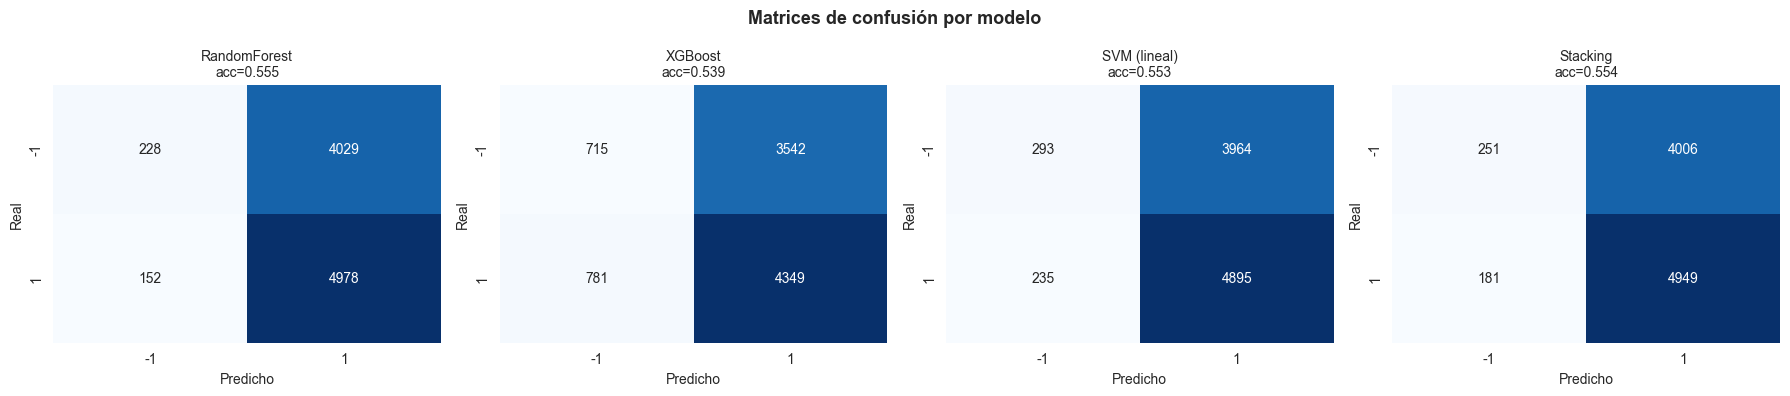

In [24]:
# Matrices de confusion de los cuatro modelos
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (nombre, r) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, r['pred'], labels=[-1, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['-1', '1'], yticklabels=['-1', '1'], ax=ax)
    ax.set_title(f"{nombre}\nacc={r['acc']:.3f}", fontsize=10)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.suptitle("Matrices de confusión por modelo", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [25]:
# Tabla resumen: accuracy vs eficiencia
resumen = pd.DataFrame({
    'Accuracy': {k: v['acc'] for k, v in resultados.items()},
    'Tiempo (s)': {k: v['tiempo'] for k, v in resultados.items()}
}).round(4).sort_values('Accuracy', ascending=False)
resumen

,Accuracy,Tiempo (s)
RandomForest,0.5546,0.6181
Stacking,0.5540,2.7841
SVM (lineal),0.5527,0.0129
XGBoost,0.5395,0.6536


En cuanto al accuracy, los cuatro modelos quedan prácticamente empatados alrededor de 0.54, lo que confirma lo de la Pregunta 4: con solo los tres factores socioemocionales no hay señal para predecir madre_work. Ni el boosting de XGBoost, ni la frontera del SVM lineal, ni la combinación del Stacking logran superar de forma relevante a un clasificador trivial.

La matriz de confusión muestra el problema de fondo. Los modelos mandan casi todo a la clase mayoritaria (empleada, valor 1) y casi no aciertan verdaderos negativos en la clase -1, de manera que la capacidad de distinguir entre ambas clases es casi nula.

Donde sí hay diferencias claras es en la velocidad de cómputo. El SVM lineal y XGBoost son los más rápidos sobre los tres features. El Random Forest sale algo más caro por el tamaño del ensamble. Y el Stacking es de lejos el más costoso, porque entrena los tres modelos base con validación cruzada interna y encima ajusta el meta-modelo, sin ganar nada de accuracy a cambio.

Como las cuatro accuracies son indistinguibles entre sí, con diferencias que caen dentro del ruido muestral, el criterio que termina decidiendo es la eficiencia. El SVM lineal consigue casi la mejor accuracy de todas, a una centésima del Random Forest, con el menor tiempo de cómputo por bastante margen, alrededor de 0.01 segundos frente a los casi 3 segundos del Stacking. Por esa relación entre accuracy y eficiencia lo elijo como mejor modelo para la Pregunta 7. El Stacking no se justifica, ya que paga el mayor costo de cómputo sin mejorar el resultado.

# 6. Clustering sobre IMCE y actividad física

Uso K-Means para agrupar a los estudiantes según su índice de masa corporal estandarizado (imce) y su frecuencia de actividad física (act_fisica). Estandarizo las dos variables para que pesen por igual y elijo el número de grupos con el método del codo y el coeficiente de silueta.

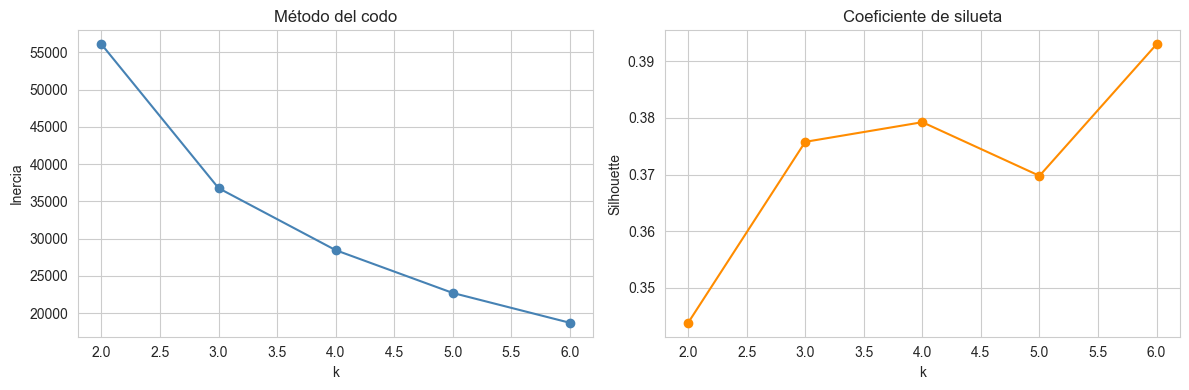

Siluetas: {2: np.float64(0.344), 3: np.float64(0.376), 4: np.float64(0.379), 5: np.float64(0.37), 6: np.float64(0.393)}


In [26]:
# Estandarizacion de las dos variables
clu_vars = ['imce', 'act_fisica']
Xc = StandardScaler().fit_transform(data[clu_vars])

# Eleccion de k: inercia (codo) + silueta
inercias, siluetas = [], []
ks = range(2, 7)
rng = np.random.RandomState(42)
idx = rng.choice(len(Xc), 5000, replace=False)   # submuestra para la silueta
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc[idx], km.labels_[idx]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inercias, 'o-', color='steelblue'); ax[0].set_title('Método del codo')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia')
ax[1].plot(list(ks), siluetas, 'o-', color='darkorange'); ax[1].set_title('Coeficiente de silueta')
ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()
print("Siluetas:", dict(zip(ks, np.round(siluetas, 3))))

In [27]:
# Ajuste final con k=3 y perfilado de los grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xc)
data['cluster'] = kmeans.labels_

perfil = data.groupby('cluster')[clu_vars].mean()
perfil['n'] = data['cluster'].value_counts().sort_index()
perfil.round(3)

,imce,act_fisica,n
cluster,,,
0,0.003,2.232,19595
1,2.217,2.239,17026
2,0.886,4.624,5233


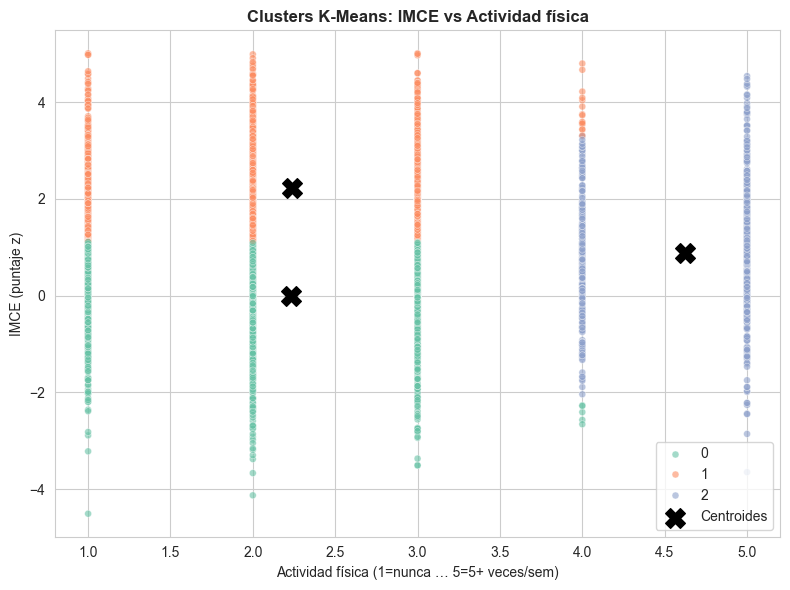

In [28]:
# Visualizacion de los clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data.sample(6000, random_state=42), x='act_fisica', y='imce',
                hue='cluster', palette='Set2', alpha=0.6, s=25)
centros = StandardScaler().fit(data[clu_vars]).inverse_transform(kmeans.cluster_centers_)
plt.scatter(centros[:, 1], centros[:, 0], c='black', marker='X', s=200, label='Centroides')
plt.title('Clusters K-Means: IMCE vs Actividad física', fontweight='bold')
plt.xlabel('Actividad física (1=nunca … 5=5+ veces/sem)'); plt.ylabel('IMCE (puntaje z)')
plt.legend(); plt.tight_layout(); plt.show()

Con k igual a 3, que es el mejor compromiso entre el codo y la silueta, K-Means separa a los estudiantes sobre todo por su nivel de actividad física y, dentro de eso, por su IMCE. Quedan así un grupo de baja actividad física, uno de actividad media y otro de actividad alta, cada uno con un IMCE promedio distinto.

El patrón que se observa es el esperable: el grupo con menos actividad física tiende a tener el mayor IMCE promedio, lo que va en línea con la relación entre sedentarismo y masa corporal. De todos modos, la separación entre grupos es modesta, con una silueta baja, porque imce y act_fisica están solo débilmente correlacionadas. El clustering describe perfiles de hábito y peso, pero no fronteras nítidas. El grupo con mayor IMCE promedio es el que usaré en la Pregunta 7.

# 7. Mejor modelo sobre el grupo de mayor IMCE

Me quedo con el cluster que tiene el IMCE promedio más alto y vuelvo a estimar sobre ese subgrupo el mejor modelo de la Pregunta 5, el SVM lineal, otra vez con los factor scores para predecir madre_work.

In [29]:
# Cluster con mayor IMCE promedio
cluster_top = perfil['imce'].idxmax()
print(f"Cluster con mayor IMCE promedio: {cluster_top} (IMCE medio = {perfil.loc[cluster_top, 'imce']:.3f})")

sub = data[(data['cluster'] == cluster_top) & (data['madre_work'] != 0)].copy()
Xs = sub[['eta1', 'eta2', 'eta3']].values
ys = (sub['madre_work'] == 1).astype(int).values
print(f"Tamaño del subgrupo: {len(sub)}")
print(f"Baseline subgrupo: {pd.Series(ys).value_counts(normalize=True).max():.4f}")

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.25,
                                              random_state=42, stratify=ys)
sc = StandardScaler().fit(Xs_tr)
Xs_tr, Xs_te = sc.transform(Xs_tr), sc.transform(Xs_te)

Cluster con mayor IMCE promedio: 1 (IMCE medio = 2.217)
Tamaño del subgrupo: 15225
Baseline subgrupo: 0.5583


Accuracy SVM lineal (subgrupo mayor IMCE): 0.5613
Tiempo: 0.01 s

              precision    recall  f1-score   support

           0       0.53      0.06      0.10      1682
           1       0.56      0.96      0.71      2125

    accuracy                           0.56      3807
   macro avg       0.55      0.51      0.41      3807
weighted avg       0.55      0.56      0.44      3807



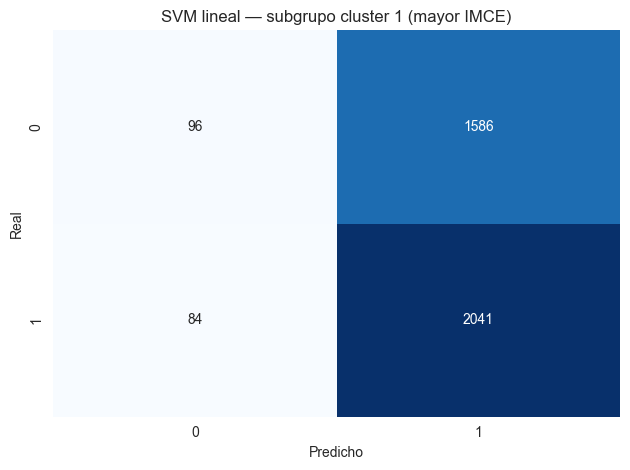

In [30]:
# Reestimacion del SVM lineal (mejor modelo de la Pregunta 5) en el subgrupo
svm_sub = LinearSVC(C=1.0, max_iter=5000, random_state=42)
t0 = time.time(); svm_sub.fit(Xs_tr, ys_tr); dt = time.time() - t0
pred_sub = svm_sub.predict(Xs_te)
print(f"Accuracy SVM lineal (subgrupo mayor IMCE): {accuracy_score(ys_te, pred_sub):.4f}")
print(f"Tiempo: {dt:.2f} s\n")
print(classification_report(ys_te, pred_sub))

cm = confusion_matrix(ys_te, pred_sub)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.title(f'SVM lineal — subgrupo cluster {cluster_top} (mayor IMCE)')
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

Restringir el entrenamiento al subgrupo de mayor IMCE promedio no mejora la capacidad predictiva: el accuracy del SVM lineal vuelve a quedar pegado al baseline del subgrupo. Esto confirma que el problema no venía de la heterogeneidad de la muestra, como si existiera un subgrupo más informativo, sino de que los factores socioemocionales simplemente no se relacionan con el empleo materno, ni en la muestra completa ni en este subgrupo en particular. Acotar por IMCE solo reduce el tamaño muestral y, con eso, aumenta la varianza de las estimaciones sin aportar señal nueva.

# 8. Análisis de la variable narrative (texto)

Siguiendo el notebook Sentiment_Analysis.ipynb, tokenizo el texto de narrative, que es una descripción generada a partir de sk1 a sk13, lo vectorizo con CountVectorizer y entreno un SVM lineal para predecir madre_work, dejando fuera las variables sk. La idea es contrastar con el SVM de la Pregunta 5, porque ambos parten de la misma información socioemocional, solo que acá codificada como texto.

In [31]:
# Stopwords en espaniol via NLTK (como en Sentiment_Analysis.ipynb), con respaldo
# por si el corpus de NLTK no esta disponible, para que el notebook corra en cualquier equipo.
try:
    nltk.download('stopwords', quiet=True)
    stops_es = set(stopwords.words('spanish'))
except Exception:
    stops_es = set((
        "de la que el en y a los del se las por un para con no una su al lo como mas pero "
        "sus le ya o este si porque esta entre cuando muy sin sobre tambien me hasta hay "
        "donde quien desde todo nos durante todos uno les ni contra otros ese eso ante ellos "
        "e esto mi antes algunos que unos yo otro otras otra el tanto esa estos mucho quienes "
        "nada muchos cual poco ella estar estas algunas algo nosotros mi mis tu te ti tus "
        "ellas nosotras vosotros vosotras os nuestro nuestra nuestros nuestras esos esas su "
        "es son fue ser bien mas asi sus lo la"
    ).split())
print(f"Stopwords en espaniol cargadas: {len(stops_es)}")

def texto_a_palabras(t):
    t = re.sub(r'#([A-Za-z_À-ÿ]+)', " ", str(t))
    palabras = t.lower().split()
    significativas = [w for w in palabras if w not in stops_es]
    return " ".join(significativas)

txt_df = data[data['madre_work'] != 0].copy()
txt_df['clean'] = txt_df['narrative'].apply(texto_a_palabras)
txt_df['clean'].head(3)

Stopwords en espaniol cargadas: 103


0    habilidades socioemocionales estan establecida...
1    exhibe perfil socioemocional solido, diferenci...
2    perfil socioemocional aun madurando, siendo in...
Name: clean, dtype: object

In [32]:
# Vectorizacion y particion train/test
Xt = txt_df['clean']
yt = txt_df['madre_work']
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, random_state=42, stratify=yt)

vect = CountVectorizer(ngram_range=(1, 2), min_df=5, max_features=2000)
Xt_tr_dtm = vect.fit_transform(Xt_tr)
Xt_te_dtm = vect.transform(Xt_te)
print(f"Matriz documento-término: {Xt_tr_dtm.shape}")

Matriz documento-término: (28158, 1234)


Accuracy SVM-texto: 0.5337 | tiempo: 6.8 s

              precision    recall  f1-score   support

          -1       0.48      0.30      0.37      4257
           1       0.56      0.73      0.63      5130

    accuracy                           0.53      9387
   macro avg       0.52      0.51      0.50      9387
weighted avg       0.52      0.53      0.51      9387



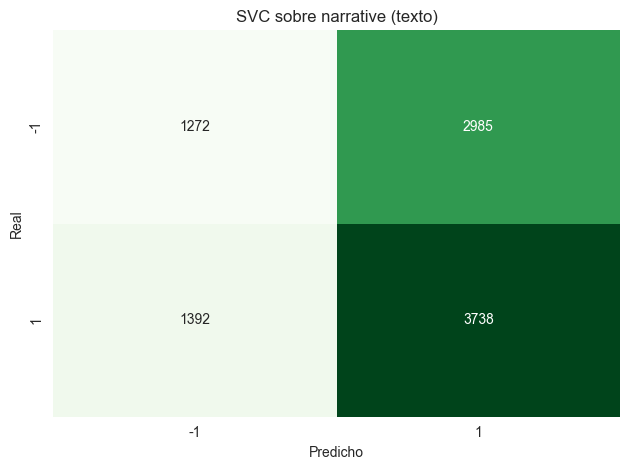

In [33]:
# SVM lineal sobre el texto (mismo tipo de clasificador que la Pregunta 5, ahora con features de texto)
t0 = time.time()
svc_txt = LinearSVC(C=1.0, max_iter=5000, random_state=10)
svc_txt.fit(Xt_tr_dtm, yt_tr)
pred_txt = svc_txt.predict(Xt_te_dtm)
dt_txt = time.time() - t0

acc_txt = accuracy_score(yt_te, pred_txt)
print(f"Accuracy SVM-texto: {acc_txt:.4f} | tiempo: {dt_txt:.1f} s\n")
print(classification_report(yt_te, pred_txt))

cm = confusion_matrix(yt_te, pred_txt, labels=[-1, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['-1', '1'], yticklabels=['-1', '1'])
plt.title('SVC sobre narrative (texto)'); plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout(); plt.show()

In [34]:
# Comparacion directa con el SVM de la Pregunta 5 (features = factor scores)
comp = pd.DataFrame({
    'Modelo': ['SVM (Pregunta 5) - factor scores', 'SVM (Pregunta 8) - texto narrative'],
    'Accuracy': [resultados['SVM (lineal)']['acc'], acc_txt],
    'Tiempo (s)': [resultados['SVM (lineal)']['tiempo'], dt_txt]
}).round(4)
comp

,Modelo,Accuracy,Tiempo (s)
0,SVM (Pregunta 5) - factor scores,0.5527,0.0129
1,SVM (Pregunta 8) - texto narrative,0.5337,6.8255


El SVM lineal entrenado sobre el texto de narrative llega a un accuracy muy parecido al del SVM de la Pregunta 5 sobre los factor scores, los dos cerca del baseline de 0.54. El resultado es coherente, porque narrative se genera a partir de los mismos sk1 a sk13 que dan origen a los factores, así que los dos enfoques contienen en el fondo la misma información socioemocional, solo que representada de manera distinta: numérica y densa en un caso, una bolsa de palabras dispersa en el otro. Como esa información no se relaciona con el empleo materno, ninguna representación logra superar al clasificador trivial.

La diferencia está en el costo. El pipeline de texto agrega la tokenización y una matriz documento-término dispersa de miles de columnas, así que entrenar sobre cerca de 28.000 documentos resulta más lento que el SVM sobre apenas tres features, aun usando el mismo solver lineal.

En resumen, pasar la información socioemocional a texto no aporta poder predictivo frente a los factores del CFA y encima encarece el cómputo. Esto refuerza el hallazgo que recorre toda la tarea: las habilidades socioemocionales del estudiante, ya sea como factores latentes o como narrativa, no predicen si la madre trabaja.